In [26]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow_hub as hub
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix

assert tf.__version__.startswith('2'), f'TF 2.x required, got {tf.__version__}'
print(f'TensorFlow: {tf.__version__}')
print(f'GPUs available: {tf.config.list_physical_devices("GPU")}')


TensorFlow: 2.21.0
GPUs available: []


In [27]:
# ── Data paths ───────────────────────────────────────────────────────────────
TRAIN_PKL        = '../data/folds-w-meta.pkl'   # pickle with train folds
TEST_PKL         = '../data/test-w-meta.pkl'     # pickle with test fold
FOLDER_IMAGE_DIR = '../data/classes/'            # optional extra labelled images

# ── Image / training hyper-parameters ────────────────────────────────────────
CLASSIFY_IMAGE_SIZE   = (75, 200)   # native resolution in the pkl files
ESTIMATE_IMAGE_SIZE   = (224, 224)  # EfficientNetB0 expects 224x224
BATCH_SIZE            = 32
CLASSIFIER_EPOCHS     = 10
ESTIMATOR_EPOCHS      = 10
SEED                = 42
EFFNET_LITE0_URL    = 'https://tfhub.dev/tensorflow/efficientnet/lite0/feature-vector/2'

# ── Size-bin definitions ──────────────────────────────────────────────────────
# Upper bound in mm → label string in cm

### Updated bin edges and labels to include more bins for better resolution
BIN_EDGES  = [250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 800, 900]
BIN_LABELS = ['25', '30', '35', '40', '45', '50', '55', '60', '65', '70', '80', '90']

### Original Bin edges and labels (edges in mm, labels in cm)
#BIN_EDGES  = [100, 150, 200, 250, 300, 350, 400, 500, 600, 700]
#BIN_LABELS = [ '10', '15', '20', '25', '30', '35', '40', '50', '60', '70']
NUM_SIZE_BINS = len(BIN_LABELS)

def length_to_bin(length_mm):
    """Map a length in mm to a size-bin index. Returns None if out of range."""
    for i, edge in enumerate(BIN_EDGES):
        if length_mm <= edge:
            return i
    return None


In [28]:
def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f, encoding='latin1')  # latin1 handles Python-2-saved pkls

train_folds = load_pkl(TRAIN_PKL)
test_folds  = load_pkl(TEST_PKL)

print(f'Train folds: {len(train_folds)}')
print(f'Keys per fold: {list(train_folds[0].keys())}')
print(f'Images in fold 0: {train_folds[0]["data"].shape}')


Train folds: 10
Keys per fold: ['fold', 'length', 'weight', 'source', 'girth', 'data', 'id', 'class']
Images in fold 0: (63, 9, 75, 200, 3)


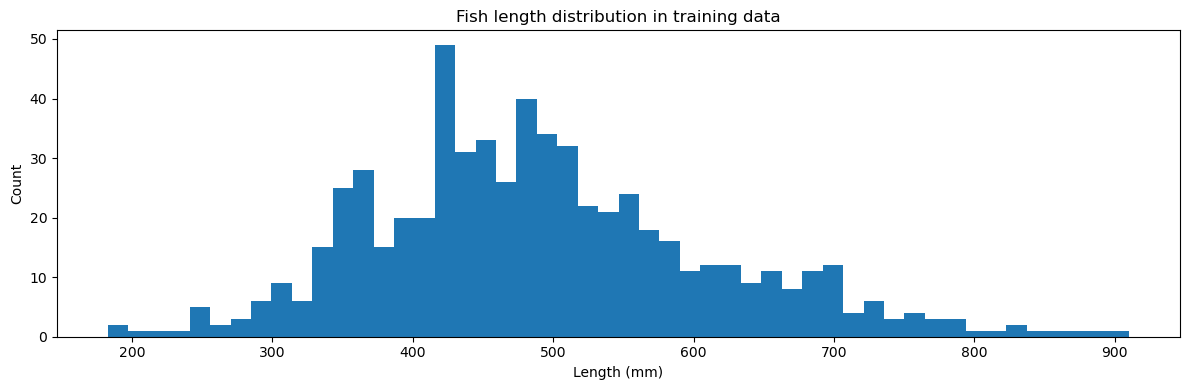

Min: 183mm, Max: 910mm, N: 623


In [29]:
all_lengths = []
for fold in train_folds:
    for length in fold['length']:
        if length is None or str(length).strip() in ('', 'NA'): continue
        all_lengths.append(float(length))

plt.figure(figsize=(12, 4))
plt.hist(all_lengths, bins=50)
plt.xlabel('Length (mm)'); plt.ylabel('Count')
plt.title('Fish length distribution in training data')
plt.tight_layout(); plt.show()

print(f'Min: {min(all_lengths):.0f}mm, Max: {max(all_lengths):.0f}mm, N: {len(all_lengths)}')

# Classification

In [30]:
TRAIN_FOLDS = list(range(0, 8))
VAL_FOLD    = 8
TEST_FOLD   = 9

def load_classification_folds(fold_indices, metadata, label_key='class'):
    """Unpack fold dicts into flat (N*9, 75, 200, 3) image arrays."""
    X_list, y_list = [], []
    for i in fold_indices:
        X = metadata[i]['data']       # (N, 9, 75, 200, 3) — 9 views per fish
        y = metadata[i][label_key]    # (N,)
        X = X.reshape(-1, 75, 200, 3)
        y = np.repeat(y, 9)
        X_list.append(X)
        y_list.append(y)
    return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)

X_cls_train, y_cls_train = load_classification_folds(TRAIN_FOLDS, train_folds)
X_cls_val,   y_cls_val   = load_classification_folds([VAL_FOLD],  train_folds)
X_cls_test,  y_cls_test  = load_classification_folds([TEST_FOLD], train_folds)

print(f'Train: {X_cls_train.shape}, Val: {X_cls_val.shape}, Test: {X_cls_test.shape}')

# Normalise
X_cls_train = X_cls_train.astype('float32') / 255.0
X_cls_val   = X_cls_val.astype('float32')   / 255.0
X_cls_test  = X_cls_test.astype('float32')  / 255.0

# Encode string species labels → integers
species_le = LabelEncoder()
species_le.fit(np.concatenate([y_cls_train, y_cls_val, y_cls_test]))
y_cls_train_enc = species_le.transform(y_cls_train)
y_cls_val_enc   = species_le.transform(y_cls_val)
y_cls_test_enc  = species_le.transform(y_cls_test)
NUM_SPECIES = len(species_le.classes_)

print(f'Species ({NUM_SPECIES}): {species_le.classes_}')


Train: (4491, 75, 200, 3), Val: (558, 75, 200, 3), Test: (558, 75, 200, 3)
Species (22): ['BHC' 'BUF' 'CC' 'CCF' 'CWS' 'FWD' 'GC' 'GF' 'GS' 'LNG' 'LNS' 'NHS' 'NP'
 'QBS' 'RHS' 'RRS' 'SC' 'SL' 'SMB' 'WB' 'WP' 'WYE']


In [31]:
import keras


classifier = keras.models.load_model("models/classifier.keras")
classifier.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 75, 200,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 75, 200,   │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 75, 200,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 37, 100,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 37, 100,   │      9,248 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 100,   │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 37, 100,   │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 100,   │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 37, 100,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 37, 100,   │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 18, 50,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 18, 50,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 18, 50,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 18, 50,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 18, 50,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 18, 50,    │      2,112 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 18, 50,    │          0 │ batch_normalizat

 Total params: 952,964 (3.64 MB)

 Trainable params: 317,334 (1.21 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 634,670 (2.42 MB)

# Size Estimator (Bins)

In [32]:
TRAIN_FOLDS = list(range(0, 9))
VAL_FOLDS   = [9]

In [33]:
def folds_to_arrays(folds, fold_indices=None):
    """
    Unpack the listed folds into (N, 224, 224, 3) float32 images and (N,) int bin labels.
    Each fish contributes 9 image entries (one per scanner view).
    """
    if fold_indices is None:
        fold_indices = list(range(len(folds)))
    X, y = [], []
    skipped_fish = 0
    for fi in fold_indices:
        fold = folds[fi]
        for i, raw in enumerate(fold['data']):           # raw: (9, 75, 200, 3)
            length = fold['length'][i]
            if length is None or str(length).strip() in ('', 'NA'):
                skipped_fish += 1; continue
            bin_idx = length_to_bin(float(length))
            if bin_idx is None:
                skipped_fish += 1; continue

            # Each fish has 9 views — emit one example per view
            for view_idx in range(raw.shape[0]):
                img = raw[view_idx].astype(np.float32)   # (75, 200, 3)
                img_resized = tf.image.resize(img, ESTIMATE_IMAGE_SIZE).numpy()
                X.append(img_resized)
                y.append(bin_idx)

    print(f'  Loaded {len(X)} images from {len(X)//9} fish, skipped {skipped_fish} fish')
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

In [34]:
X_all, y_all = folds_to_arrays(train_folds + test_folds)
X_train, X_temp, y_train, y_temp = train_test_split(X_all, y_all, test_size=0.2)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

print(f'\nTrain: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')
print(f'Train bin counts: {np.bincount(y_train, minlength=NUM_SIZE_BINS)}')
print(f'Val   bin counts: {np.bincount(y_val,   minlength=NUM_SIZE_BINS)}')
print(f'Test  bin counts: {np.bincount(y_test,  minlength=NUM_SIZE_BINS)}')

  Loaded 6237 images from 693 fish, skipped 1 fish

Train: 4989  Val: 624  Test: 624
Train bin counts: [ 66 105 324 562 935 940 692 466 325 285 214  75]
Val   bin counts: [  7  17  44  69 111 116  96  55  39  37  24   9]
Test  bin counts: [  8  13  46  71 115 114  85  73  32  38  23   6]


In [35]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
            .shuffle(len(X_train), seed=SEED)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))
val_ds   = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
            .batch(BATCH_SIZE).cache().prefetch(AUTOTUNE))
test_ds  = (tf.data.Dataset.from_tensor_slices((X_test, y_test))
            .batch(BATCH_SIZE).cache().prefetch(AUTOTUNE))

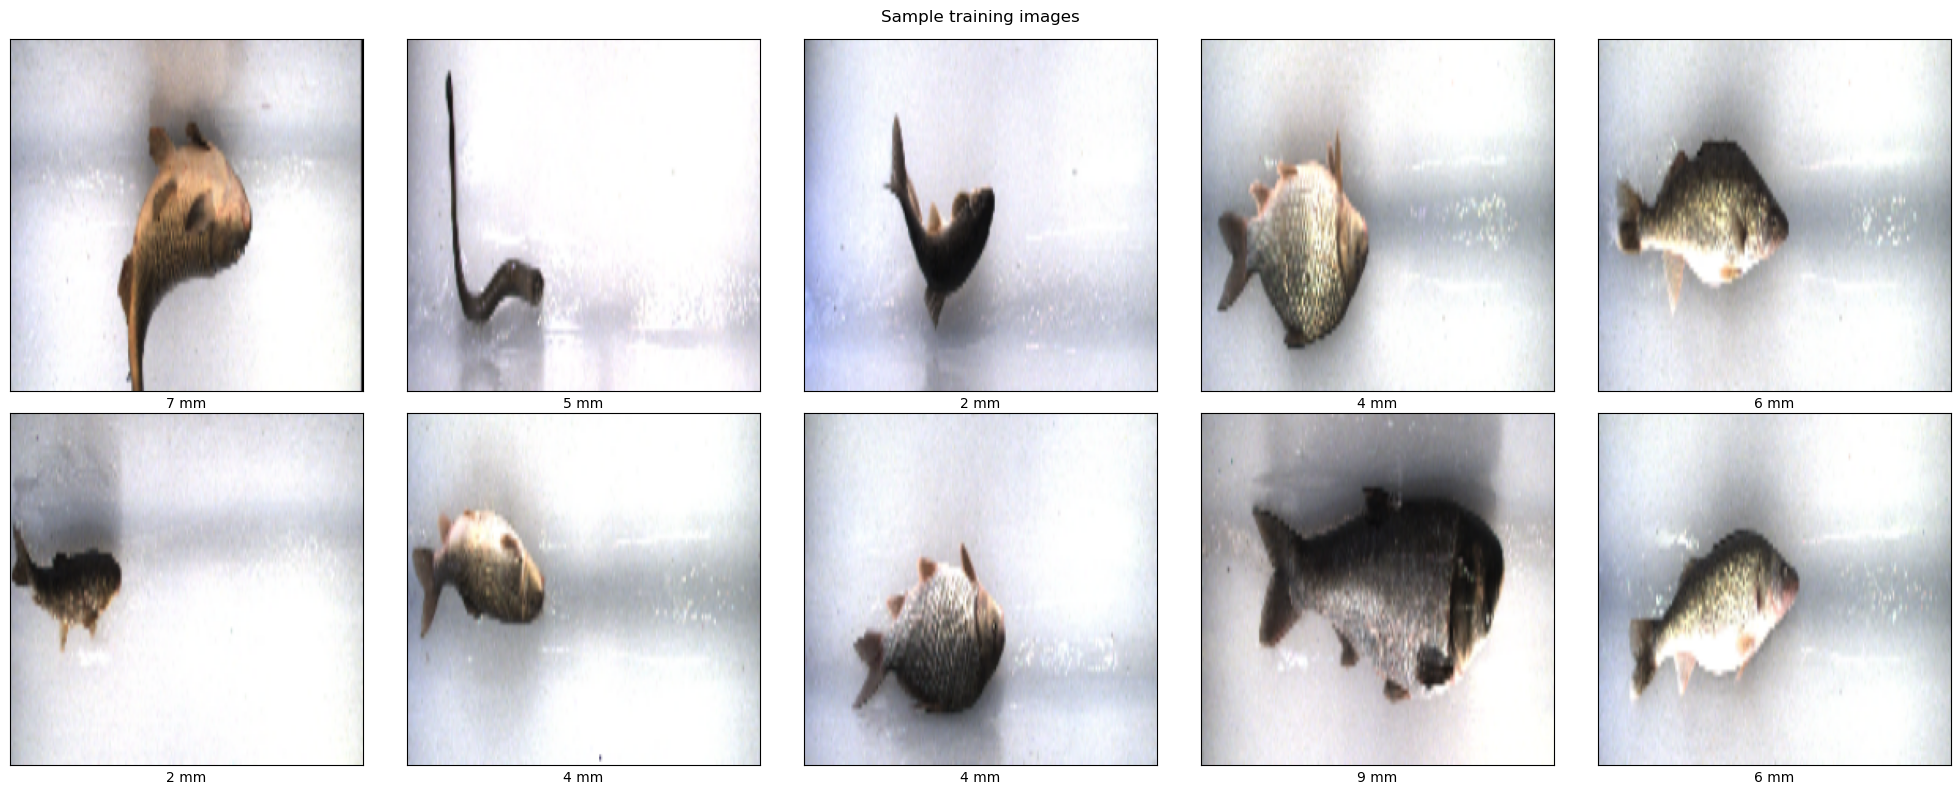

In [36]:
plt.figure(figsize=(20, 8))
for imgs, lbls in train_ds.take(1):
    for i in range(min(10, imgs.shape[0])):
        plt.subplot(2, 5, i + 1)
        plt.xticks([]); plt.yticks([]); plt.grid(False)
        plt.imshow(imgs[i].numpy().astype('uint8'))
        plt.xlabel(f'{lbls[i].numpy():.0f} mm')
plt.suptitle('Sample training images')
plt.tight_layout(); plt.show()

## Build Estimator Model

In [37]:
def build_estimator(num_classes, trainable_backbone=False):
    backbone = hub.KerasLayer(
        EFFNET_LITE0_URL,
        trainable=trainable_backbone,
        input_shape=ESTIMATE_IMAGE_SIZE + (3,),
    )
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=ESTIMATE_IMAGE_SIZE + (3,)),
        tf.keras.layers.Rescaling(1.0 / 255.0),   # [0,255] → [0,1] for Lite0
        backbone,
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation='softmax'),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

estimator = tf.keras.models.load_model("models/estimator_bins_original.keras", custom_objects={"KerasLayer": hub.KerasLayer}) #build_estimator(NUM_SIZE_BINS, trainable_backbone=False)
estimator.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 224, 224, 3)       0         
                                                                 
 keras_layer_1 (KerasLayer)  (None, 1280)              3413024   
                                                                 
 dropout_1 (Dropout)         (None, 1280)              0         
                                                                 
 dense_1 (Dense)             (None, 12)                15372     
                                                                 
Total params: 3428396 (13.08 MB)
Trainable params: 15372 (60.05 KB)
Non-trainable params: 3413024 (13.02 MB)
_________________________________________________________________


## Train Model

In [38]:
# Class weights for bin imbalance (small/large fish are rare in Silva's data)
unique_bins = np.unique(y_train)
weights_arr = compute_class_weight('balanced', classes=unique_bins, y=y_train)
class_weights = dict(zip(unique_bins.tolist(), weights_arr.tolist()))
for c in range(NUM_SIZE_BINS):
    class_weights.setdefault(c, 1.0)
print(f'Class weights: {class_weights}')

early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

history = estimator.fit(
    train_ds,
    validation_data=val_ds,
    epochs=ESTIMATOR_EPOCHS
    # Below options not used by Silva but do improve accuracy
    #class_weight=class_weights,
    #callbacks=[early_stop],
)

Class weights: {0: 6.299242424242424, 1: 3.9595238095238097, 2: 1.283179012345679, 3: 0.7397686832740213, 4: 0.4446524064171123, 5: 0.4422872340425532, 6: 0.6007947976878613, 7: 0.8921673819742489, 8: 1.2792307692307692, 9: 1.4587719298245614, 10: 1.9427570093457944, 11: 5.543333333333333}
Epoch 1/10
156/156 [==============================] - 18s 106ms/step - loss: 0.9298 - accuracy: 0.6452 - val_loss: 0.8431 - val_accuracy: 0.7179
Epoch 2/10
156/156 [==============================] - 17s 108ms/step - loss: 0.9000 - accuracy: 0.6629 - val_loss: 0.8514 - val_accuracy: 0.6795
Epoch 3/10
156/156 [==============================] - 16s 101ms/step - loss: 0.8730 - accuracy: 0.6805 - val_loss: 0.8410 - val_accuracy: 0.6795
Epoch 4/10
156/156 [==============================] - 16s 100ms/step - loss: 0.8402 - accuracy: 0.6927 - val_loss: 0.8426 - val_accuracy: 0.6843
Epoch 5/10
156/156 [==============================] - 16s 101ms/step - loss: 0.8268 - accuracy: 0.7007 - val_loss: 0.8379 - val_a

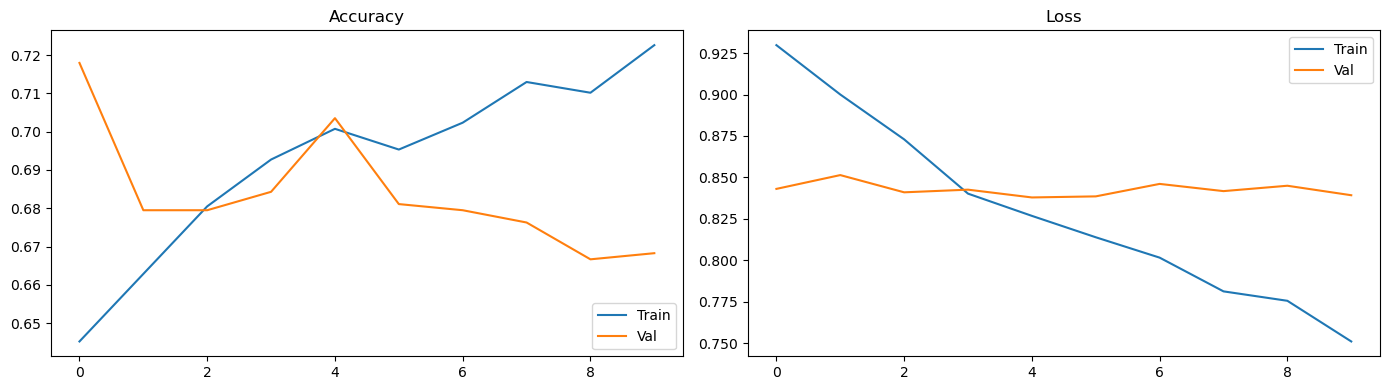

Train  — loss: 0.6378, accuracy: 79.82%
Val    — loss: 0.8392, accuracy: 66.83%
Test   — loss: 0.8519, accuracy: 66.19%


In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy'); ax1.legend()
ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss'); ax2.legend()
plt.tight_layout(); plt.show()

for ds, name in [(train_ds, 'Train'), (val_ds, 'Val'), (test_ds, 'Test')]:
    loss, acc = estimator.evaluate(ds, verbose=0)
    print(f'{name:<6} — loss: {loss:.4f}, accuracy: {acc:.2%}')

## Combined Inference

Blends the estimator's softmax output with the classifier's species-informed size distribution. **`alpha`** is the weight on the **estimator**; `(1 - alpha)` is the weight on the species-informed prior (`SPECIES_SIZE_PRIOR` from `configs/species_priors_by_code.yaml`).

- **Baselines:** `α=1.0` (estimator only), `α=0.0` (prior only)
- **Sweep:** test many `α` values on the aligned test set and pick the best for the confusion matrix

In [40]:
# ── Biological priors: P(size bin | species) ───────────────────────────────────
from pathlib import Path

PRIORS_BY_CODE_PATH = Path('../configs/species_priors_by_code.yaml')


def load_species_priors_by_code(path):
    """Load mean/min/max priors from simple YAML (no PyYAML dependency)."""
    priors = {}
    species = None
    for raw in Path(path).read_text().splitlines():
        line = raw.split('#', 1)[0].strip()
        if not line:
            continue
        if line.endswith(':') and ' ' not in line.rstrip(':'):
            species = line[:-1].strip()
            priors[species] = {}
            continue
        if species is None:
            continue
        key, _, val = line.partition(':')
        if val.strip():
            priors[species][key.strip()] = float(val.strip())
    return priors


def build_prior_matrix(species_classes, bin_labels, priors_by_code, sigma_scale=0.25):
    """Truncated Gaussian over bin centers; uniform row if species stats missing."""
    bin_centers = np.array([float(label) for label in bin_labels], dtype=np.float32)
    num_species = len(species_classes)
    num_bins = len(bin_labels)
    matrix = np.zeros((num_species, num_bins), dtype=np.float32)
    uniform = np.full(num_bins, 1.0 / num_bins, dtype=np.float32)

    for i, code in enumerate(species_classes):
        stats = priors_by_code.get(code)
        if not stats:
            matrix[i] = uniform
            continue
        mu = stats['mean_length_cm']
        lo = stats['min_length_cm']
        hi = stats['max_length_cm']
        sigma = max((hi - lo) * sigma_scale, 1.0)
        w = np.exp(-0.5 * ((bin_centers - mu) / sigma) ** 2)
        w *= (bin_centers >= lo) & (bin_centers <= hi)
        matrix[i] = w / w.sum() if w.sum() > 0 else uniform

    return matrix


priors_by_code = load_species_priors_by_code(PRIORS_BY_CODE_PATH)
SPECIES_SIZE_PRIOR = build_prior_matrix(species_le.classes_, BIN_LABELS, priors_by_code)

assert SPECIES_SIZE_PRIOR.shape == (NUM_SPECIES, NUM_SIZE_BINS)
assert np.allclose(SPECIES_SIZE_PRIOR.sum(axis=1), 1.0)

mapped = sum(1 for c in species_le.classes_ if c in priors_by_code)
print(
    f'Biological priors: {mapped}/{NUM_SPECIES} species with stats, '
    f'{NUM_SPECIES - mapped} uniform fallback rows'
)


Biological priors: 22/22 species with stats, 0 uniform fallback rows


In [41]:
def predict_combined(images_224, images_75_200, alpha=0.5):
    """
    Predict size bins by blending the size estimator and species classifier outputs.

    Parameters
    ----------
    images_224    : (N, 224, 224, 3) float32 — input for the size estimator
    images_75_200 : (N,  75, 200, 3) float32 — input for the species classifier
    alpha         : float in [0, 1] — weight on the estimator (1 = estimator only, 0 = prior only)

    Returns
    -------
    pred_bins : (N,) int array of predicted size-bin indices
    """
    # Size estimator: P(bin | image)
    est_probs = estimator.predict(images_224, verbose=0)          # (N, NUM_SIZE_BINS)

    # Classifier: P(species | image)
    species_probs = classifier.predict(images_75_200, verbose=0)  # (N, NUM_SPECIES)

    # Species-informed size prior: P(bin) = sum_s P(species=s|image) * P(bin|species=s)
    prior_scores = species_probs @ SPECIES_SIZE_PRIOR              # (N, NUM_SIZE_BINS)

    combined  = alpha * est_probs + (1 - alpha) * prior_scores
    pred_bins = np.argmax(combined, axis=1)
    return pred_bins


# ── Build the 75x200 test set (needed by the classifier) ─────────────────────
# Note: reshape to (75, 200, 3) explicitly — (-1, 200, 3) would incorrectly
# collapse all rows across the batch into a single dimension.
X_test_75_list = []
X_est_test_list = []
y_est_test_list = []

for fold in test_folds:
    for i, raw in enumerate(fold['data']):
        length = fold['length'][i]
        if length is None or str(length).strip() in ('', 'NA'): continue
        bin_idx = length_to_bin(float(length))
        if bin_idx is None: continue

        # One 75x200 view (view 0) per fish for the classifier
        img_75 = np.reshape(raw, (9, 75, 200, 3))[0].astype(np.float32) / 255.0
        X_test_75_list.append(img_75)

        # One 224x224 image per fish for the estimator
        img_224 = tf.image.resize(
            np.reshape(raw, (9, 75, 200, 3))[0].astype(np.float32),
            ESTIMATE_IMAGE_SIZE
        ).numpy()
        X_est_test_list.append(img_224)

        y_est_test_list.append(bin_idx)

X_test_75       = np.array(X_test_75_list,  dtype=np.float32)
X_est_test_norm = np.array(X_est_test_list, dtype=np.float32)
y_est_test_aligned = np.array(y_est_test_list, dtype=np.int32)
print(f'Aligned test set: {len(y_est_test_aligned)} fish')


Aligned test set: 71 fish


Alpha baselines (aligned test set):
  Estimator only (α=1.0)       69.01%
  Prior only (α=0.0)           11.27%
  Equal blend (α=0.5)          70.42%

Best α = 0.15  →  accuracy 74.65%


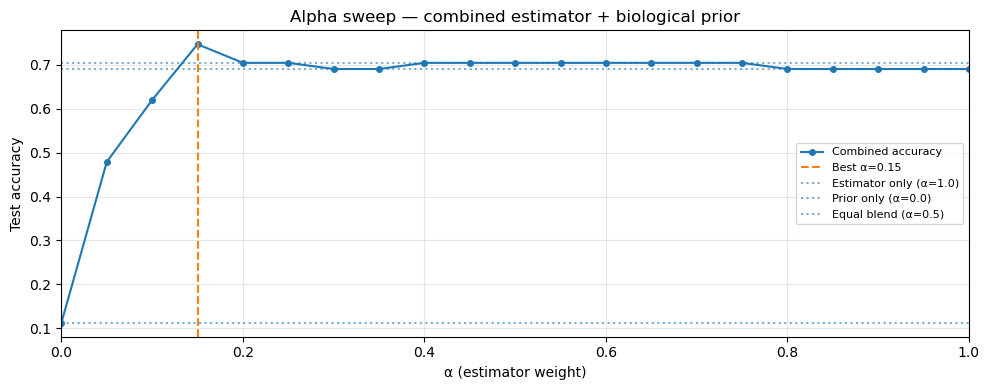

In [42]:
# ── Alpha baselines & sweep (single predict pass, then blend) ─────────────────
y_true = y_est_test_aligned

est_probs     = estimator.predict(X_est_test_norm, verbose=0)       # (N, NUM_SIZE_BINS)
species_probs = classifier.predict(X_test_75, verbose=0)            # (N, NUM_SPECIES)
prior_scores  = species_probs @ SPECIES_SIZE_PRIOR                    # (N, NUM_SIZE_BINS)


def blend_and_predict(alpha):
    combined = alpha * est_probs + (1.0 - alpha) * prior_scores
    return np.argmax(combined, axis=1)


def bin_accuracy(preds):
    return np.mean(preds == y_true)


# ── Baselines ─────────────────────────────────────────────────────────────────
ALPHA_BASELINES = [
    (1.0, 'Estimator only (α=1.0)'),
    (0.0, 'Prior only (α=0.0)'),
    (0.5, 'Equal blend (α=0.5)'),
]

print('Alpha baselines (aligned test set):')
for alpha, label in ALPHA_BASELINES:
    acc = bin_accuracy(blend_and_predict(alpha))
    print(f'  {label:<28} {acc:.2%}')

# ── Sweep ─────────────────────────────────────────────────────────────────────
ALPHAS = np.round(np.arange(0.0, 1.01, 0.05), 2)
sweep_acc = [bin_accuracy(blend_and_predict(a)) for a in ALPHAS]

best_idx   = int(np.argmax(sweep_acc))
BEST_ALPHA = float(ALPHAS[best_idx])
best_acc   = sweep_acc[best_idx]

print(f'\nBest α = {BEST_ALPHA:.2f}  →  accuracy {best_acc:.2%}')

# ── Plot sweep ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ALPHAS, sweep_acc, marker='o', markersize=4, label='Combined accuracy')
ax.axvline(BEST_ALPHA, color='C1', ls='--', label=f'Best α={BEST_ALPHA:.2f}')
for alpha, label in ALPHA_BASELINES:
    acc = bin_accuracy(blend_and_predict(alpha))
    ax.axhline(acc, ls=':', alpha=0.6, label=label)
ax.set_xlabel('α (estimator weight)')
ax.set_ylabel('Test accuracy')
ax.set_title('Alpha sweep — combined estimator + biological prior')
ax.set_xlim(0, 1)
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Predictions at best α for confusion matrix below
pred_bins = blend_and_predict(BEST_ALPHA)


### Confusion matrix — combined pipeline (best α from sweep)

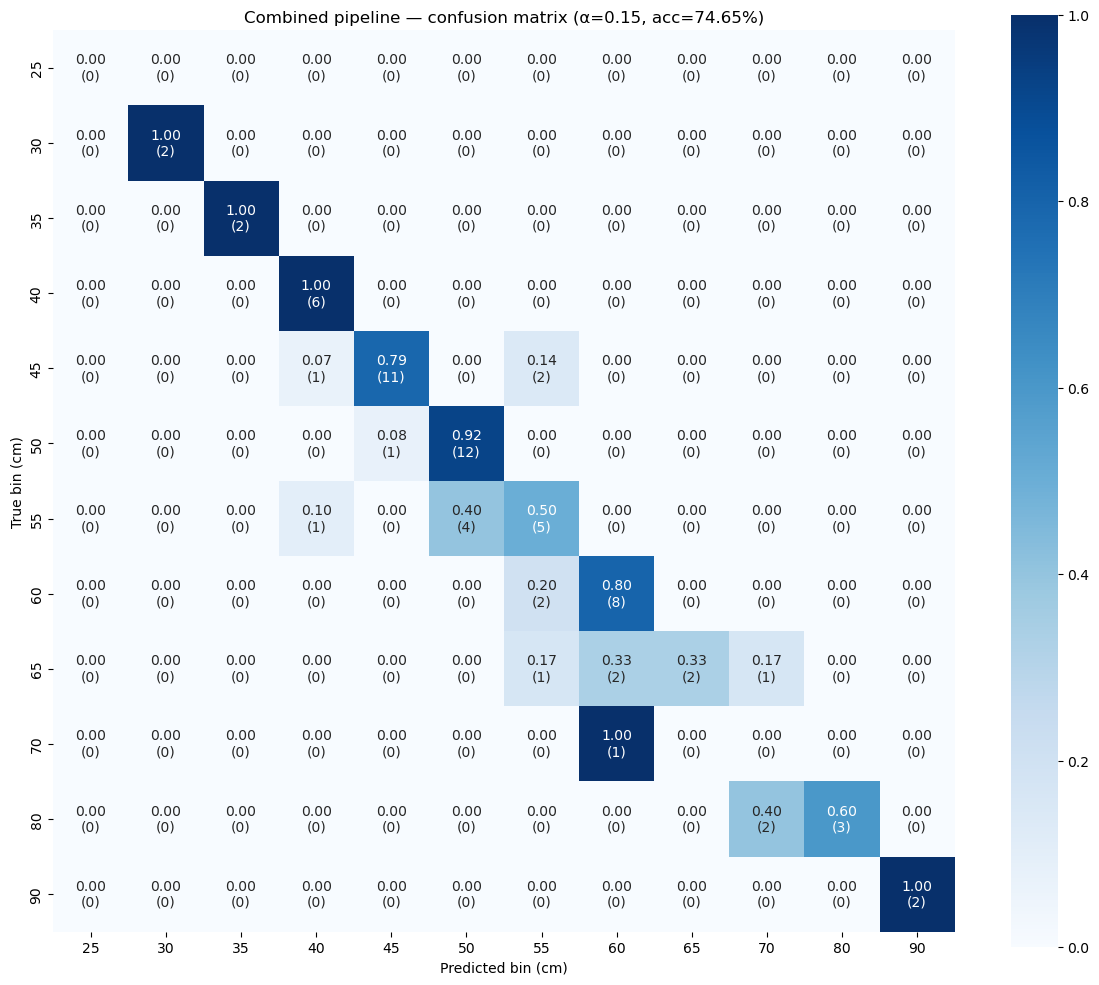

In [43]:
cm      = confusion_matrix(y_est_test_aligned, pred_bins, labels=list(range(NUM_SIZE_BINS)))
row_sum = cm.sum(axis=1, keepdims=True)
cm_norm = np.where(row_sum == 0, 0, cm.astype('float') / np.where(row_sum == 0, 1, row_sum))
annot   = np.array([[f'{cm_norm[i,j]:.2f}\n({cm[i,j]})' for j in range(NUM_SIZE_BINS)]
                     for i in range(NUM_SIZE_BINS)])

plt.figure(figsize=(12, 10))
sns.heatmap(cm_norm, xticklabels=BIN_LABELS, yticklabels=BIN_LABELS,
            cmap='Blues', annot=annot, fmt='', square=True, vmin=0, vmax=1)
plt.title(f'Combined pipeline — confusion matrix (α={BEST_ALPHA:.2f}, acc={best_acc:.2%})')
plt.ylabel('True bin (cm)'); plt.xlabel('Predicted bin (cm)')
plt.tight_layout(); plt.show()


# Eval Code

In [44]:
# ── 20-run evaluation of combined pipeline (using BEST_ALPHA from sweep) ──────

NUM_RUNS = 20
AUTOTUNE = tf.data.AUTOTUNE

# 1. Pool ALL data at both resolutions ─────────────────────────────────────────
print('Pooling all data at 224x224 for estimator...')
X_all_224, y_all_bins = folds_to_arrays(train_folds + test_folds)

print('Pooling all data at 75x200 for classifier...')
X_all_75 = []
y_all_species = []
for fold in (train_folds + test_folds):
    for i, raw in enumerate(fold['data']):
        length = fold['length'][i]
        if length is None or str(length).strip() in ('', 'NA'): continue
        bin_idx = length_to_bin(float(length))
        if bin_idx is None: continue
        species = fold['class'][i]
        for v in range(raw.shape[0]):
            img_75 = raw[v].astype(np.float32) / 255.0
            X_all_75.append(img_75)
            y_all_species.append(species)

X_all_75 = np.array(X_all_75, dtype=np.float32)
y_all_species = np.array(y_all_species)
print(f'Total: {X_all_224.shape[0]} images (224x224), {X_all_75.shape[0]} images (75x200)\n')

assert len(X_all_224) == len(X_all_75), "Image counts don't match — check filtering logic"

# 2. Run loop ──────────────────────────────────────────────────────────────────
results = []
all_cm_combined  = np.zeros((NUM_SIZE_BINS, NUM_SIZE_BINS), dtype=np.float64)
all_cm_estimator = np.zeros((NUM_SIZE_BINS, NUM_SIZE_BINS), dtype=np.float64)
per_run_cm_estimator = []
per_run_cm_combined  = []

for run in range(NUM_RUNS):
    seed = run
    print(f'═══ Run {run + 1}/{NUM_RUNS}  (seed={seed}) ═══')

    # Split at image level (matching Silva)
    idx = np.arange(len(X_all_224))
    idx_tr, idx_temp = train_test_split(idx, test_size=0.2, random_state=seed)
    idx_val, idx_te  = train_test_split(idx_temp, test_size=0.5, random_state=seed)

    X_tr_224 = X_all_224[idx_tr]
    y_tr     = y_all_bins[idx_tr]
    X_v_224  = X_all_224[idx_val]
    X_v_75   = X_all_75[idx_val]
    y_v      = y_all_bins[idx_val]
    X_te_224 = X_all_224[idx_te]
    X_te_75  = X_all_75[idx_te]
    y_te     = y_all_bins[idx_te]

    # Build datasets for estimator training
    train_ds = (tf.data.Dataset.from_tensor_slices((X_tr_224, y_tr))
                .shuffle(len(X_tr_224), seed=seed).batch(BATCH_SIZE).prefetch(AUTOTUNE))
    val_ds   = (tf.data.Dataset.from_tensor_slices((X_v_224, y_v))
                .batch(BATCH_SIZE).prefetch(AUTOTUNE))

    # Fresh estimator each run
    model = build_estimator(NUM_SIZE_BINS, trainable_backbone=False)
    model.fit(train_ds, validation_data=val_ds, epochs=ESTIMATOR_EPOCHS, verbose=0)

    # ── Evaluate: estimator only (α=1.0) ──────────────────────────────────
    est_probs = model.predict(X_te_224, verbose=0)
    est_preds = np.argmax(est_probs, axis=1)
    est_acc   = np.mean(est_preds == y_te)

    # ── Evaluate: combined (α=BEST_ALPHA) ─────────────────────────────────
    # Inside the run loop, after training the model:

    # ── Predictions on val and test ───────────────────────────────────────
    est_probs_val = model.predict(X_v_224, verbose=0)
    sp_probs_val  = classifier.predict(X_v_75, verbose=0)
    prior_val     = sp_probs_val @ SPECIES_SIZE_PRIOR

    est_probs_te  = model.predict(X_te_224, verbose=0)
    sp_probs_te   = classifier.predict(X_te_75, verbose=0)
    prior_te      = sp_probs_te @ SPECIES_SIZE_PRIOR

    # ── Sweep alpha on VAL set ────────────────────────────────────────────
    ALPHAS = np.round(np.arange(0.0, 1.01, 0.05), 2)
    val_accs = []
    for a in ALPHAS:
        combined_val = a * est_probs_val + (1 - a) * prior_val
        preds_val = np.argmax(combined_val, axis=1)
        val_accs.append(np.mean(preds_val == y_v))

    run_best_alpha = float(ALPHAS[np.argmax(val_accs)])

    # ── Evaluate on TEST set ──────────────────────────────────────────────
    # Estimator only
    est_preds = np.argmax(est_probs_te, axis=1)
    est_acc   = np.mean(est_preds == y_te)

    # Combined at this run's best alpha
    combined_te = run_best_alpha * est_probs_te + (1 - run_best_alpha) * prior_te
    comb_preds  = np.argmax(combined_te, axis=1)
    comb_acc    = np.mean(comb_preds == y_te)

    results.append({
        'run': run + 1,
        'seed': seed,
        'best_alpha': run_best_alpha,
        'estimator_acc': est_acc,
        'combined_acc': comb_acc,
    })
    print(f'  Best α (val): {run_best_alpha:.2f}  '
        f'Estimator acc: {est_acc:.2%}  Combined acc: {comb_acc:.2%}\n')

    # Accumulate normalised confusion matrices
    for preds, cm_accum, per_run_list in [(est_preds,  all_cm_estimator, per_run_cm_estimator),    (comb_preds, all_cm_combined,  per_run_cm_combined),]:
        cm = confusion_matrix(y_te, preds, labels=list(range(NUM_SIZE_BINS)))
        row_sum = cm.sum(axis=1, keepdims=True)
        cm_norm = np.where(row_sum == 0, 0, cm / np.where(row_sum == 0, 1, row_sum))
        cm_accum += cm_norm
        per_run_list.append(cm_norm)

    # Free memory
    del model, est_probs_val, est_probs_te, sp_probs_val, sp_probs_te, X_tr_224, X_v_224, X_te_224, X_te_75, X_v_75
    tf.keras.backend.clear_session()

Pooling all data at 224x224 for estimator...
  Loaded 6237 images from 693 fish, skipped 1 fish
Pooling all data at 75x200 for classifier...
Total: 6237 images (224x224), 6237 images (75x200)

═══ Run 1/20  (seed=0) ═══
  Best α (val): 0.90  Estimator acc: 58.01%  Combined acc: 58.01%

═══ Run 2/20  (seed=1) ═══
  Best α (val): 1.00  Estimator acc: 57.05%  Combined acc: 57.05%

═══ Run 3/20  (seed=2) ═══
  Best α (val): 0.45  Estimator acc: 56.25%  Combined acc: 56.09%

═══ Run 4/20  (seed=3) ═══
  Best α (val): 0.60  Estimator acc: 58.17%  Combined acc: 58.49%

═══ Run 5/20  (seed=4) ═══
  Best α (val): 0.80  Estimator acc: 59.62%  Combined acc: 59.62%

═══ Run 6/20  (seed=5) ═══
  Best α (val): 0.40  Estimator acc: 57.05%  Combined acc: 55.61%

═══ Run 7/20  (seed=6) ═══
  Best α (val): 0.30  Estimator acc: 59.94%  Combined acc: 59.62%

═══ Run 8/20  (seed=7) ═══
  Best α (val): 0.35  Estimator acc: 58.49%  Combined acc: 58.17%

═══ Run 9/20  (seed=8) ═══
  Best α (val): 0.30  Estima

In [45]:
# ── Summary ───────────────────────────────────────────────────────────────────
df = pd.DataFrame(results)
print(df.to_string(index=False))
print(f'\nBest α across runs: {df["best_alpha"].mean():.2f} ± {df["best_alpha"].std():.2f}')
print(f'  Range: {df["best_alpha"].min():.2f} — {df["best_alpha"].max():.2f}')
print(f'\nEstimator only:  {df["estimator_acc"].mean():.2%} ± {df["estimator_acc"].std():.2%}')
print(f'Combined:        {df["combined_acc"].mean():.2%} ± {df["combined_acc"].std():.2%}')
print(f'Δ accuracy:      {(df["combined_acc"].mean() - df["estimator_acc"].mean()):+.2%}')

 run  seed  best_alpha  estimator_acc  combined_acc
   1     0        0.90       0.580128      0.580128
   2     1        1.00       0.570513      0.570513
   3     2        0.45       0.562500      0.560897
   4     3        0.60       0.581731      0.584936
   5     4        0.80       0.596154      0.596154
   6     5        0.40       0.570513      0.556090
   7     6        0.30       0.599359      0.596154
   8     7        0.35       0.584936      0.581731
   9     8        0.30       0.599359      0.588141
  10     9        0.60       0.628205      0.628205
  11    10        0.75       0.576923      0.580128
  12    11        0.45       0.600962      0.596154
  13    12        0.35       0.625000      0.610577
  14    13        0.85       0.618590      0.616987
  15    14        0.50       0.594551      0.594551
  16    15        0.40       0.591346      0.597756
  17    16        0.90       0.607372      0.607372
  18    17        0.60       0.533654      0.525641
  19    18  

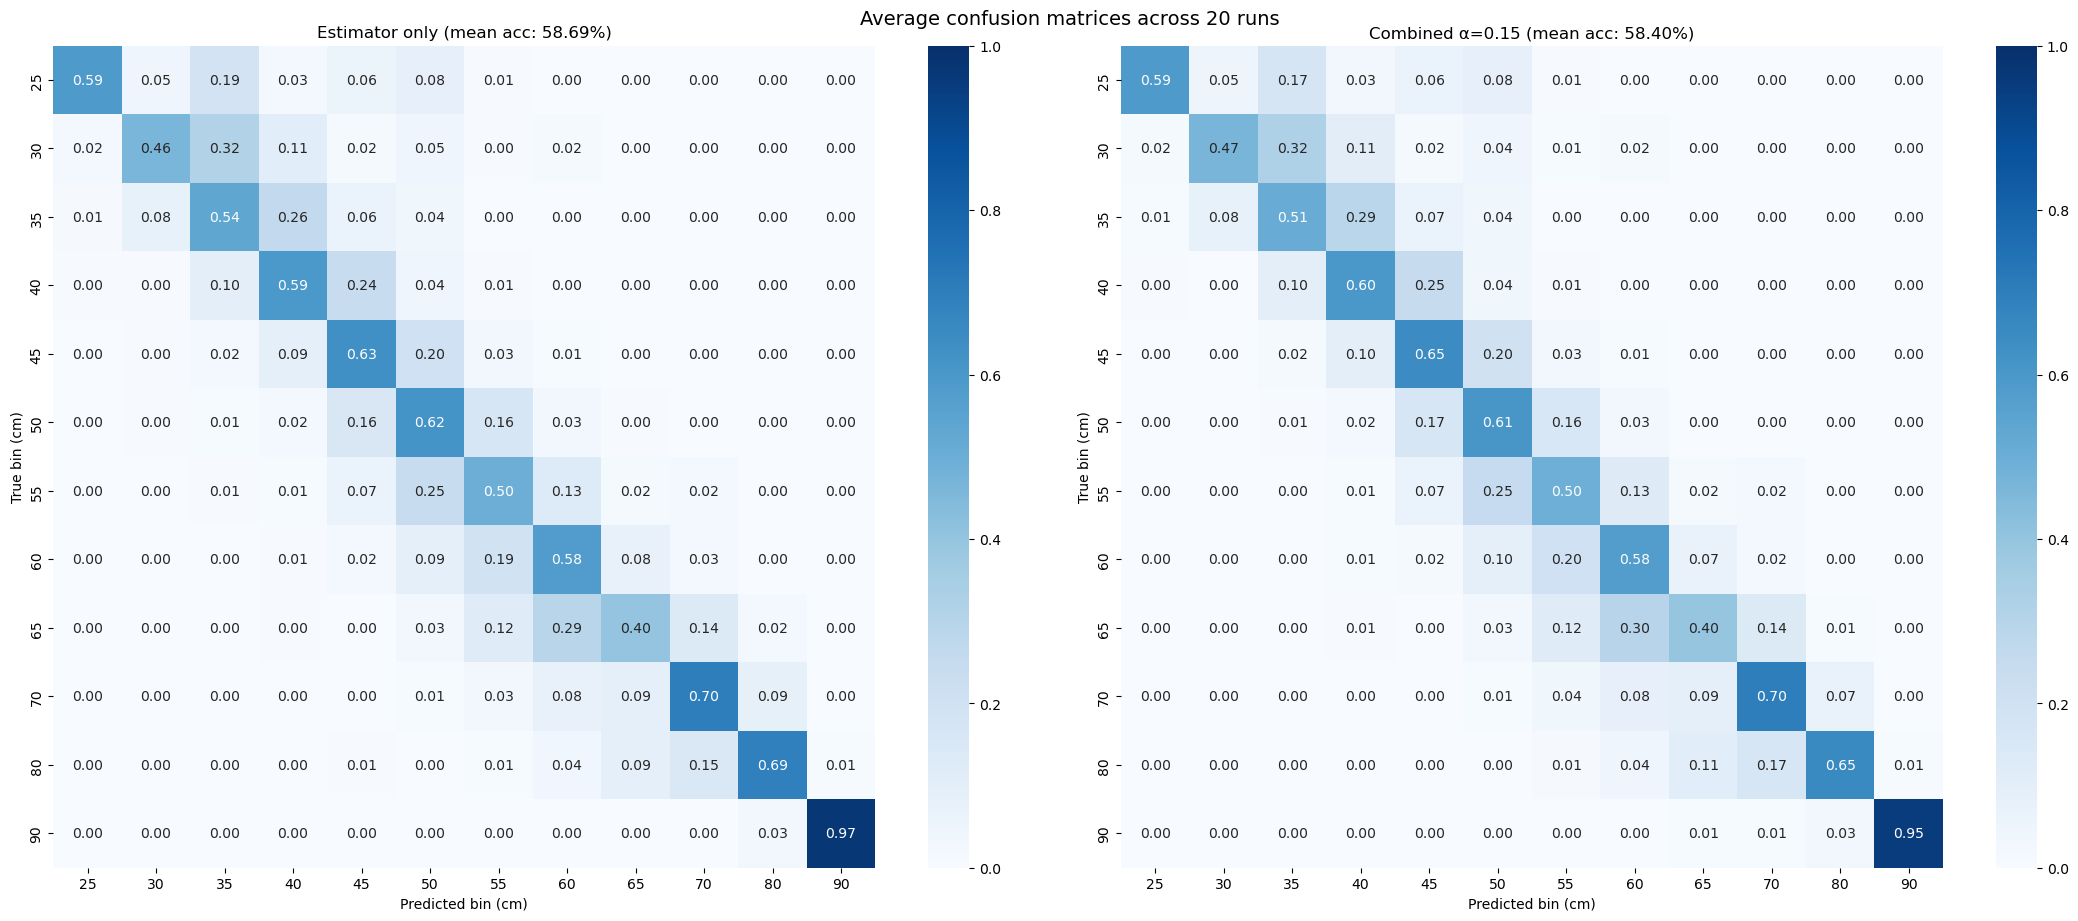

In [46]:
# ── Average confusion matrices ────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))

for ax, cm_accum, title in [
    (ax1, all_cm_estimator, f'Estimator only (mean acc: {df["estimator_acc"].mean():.2%})'),
    (ax2, all_cm_combined,  f'Combined α={BEST_ALPHA:.2f} (mean acc: {df["combined_acc"].mean():.2%})'),
]:
    avg = cm_accum / NUM_RUNS
    sns.heatmap(avg, xticklabels=BIN_LABELS, yticklabels=BIN_LABELS,
                cmap='Blues', annot=True, fmt='.2f', square=True, vmin=0, vmax=1, ax=ax)
    ax.set_title(title)
    ax.set_ylabel('True bin (cm)')
    ax.set_xlabel('Predicted bin (cm)')

plt.suptitle(f'Average confusion matrices across {NUM_RUNS} runs', fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\jettg\AppData\Local\Temp\ipykernel_18280\1719445443.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=bin_labels, showfliers=True)
C:\Users\jettg\AppData\Local\Temp\ipykernel_18280\1719445443.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=bin_labels, showfliers=True)
C:\Users\jettg\AppData\Local\Temp\ipykernel_18280\1719445443.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=bin_labels, showfliers=True)
C:\Users\jettg\AppData\Local\Temp\ipykernel_18280\1719445443.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of 

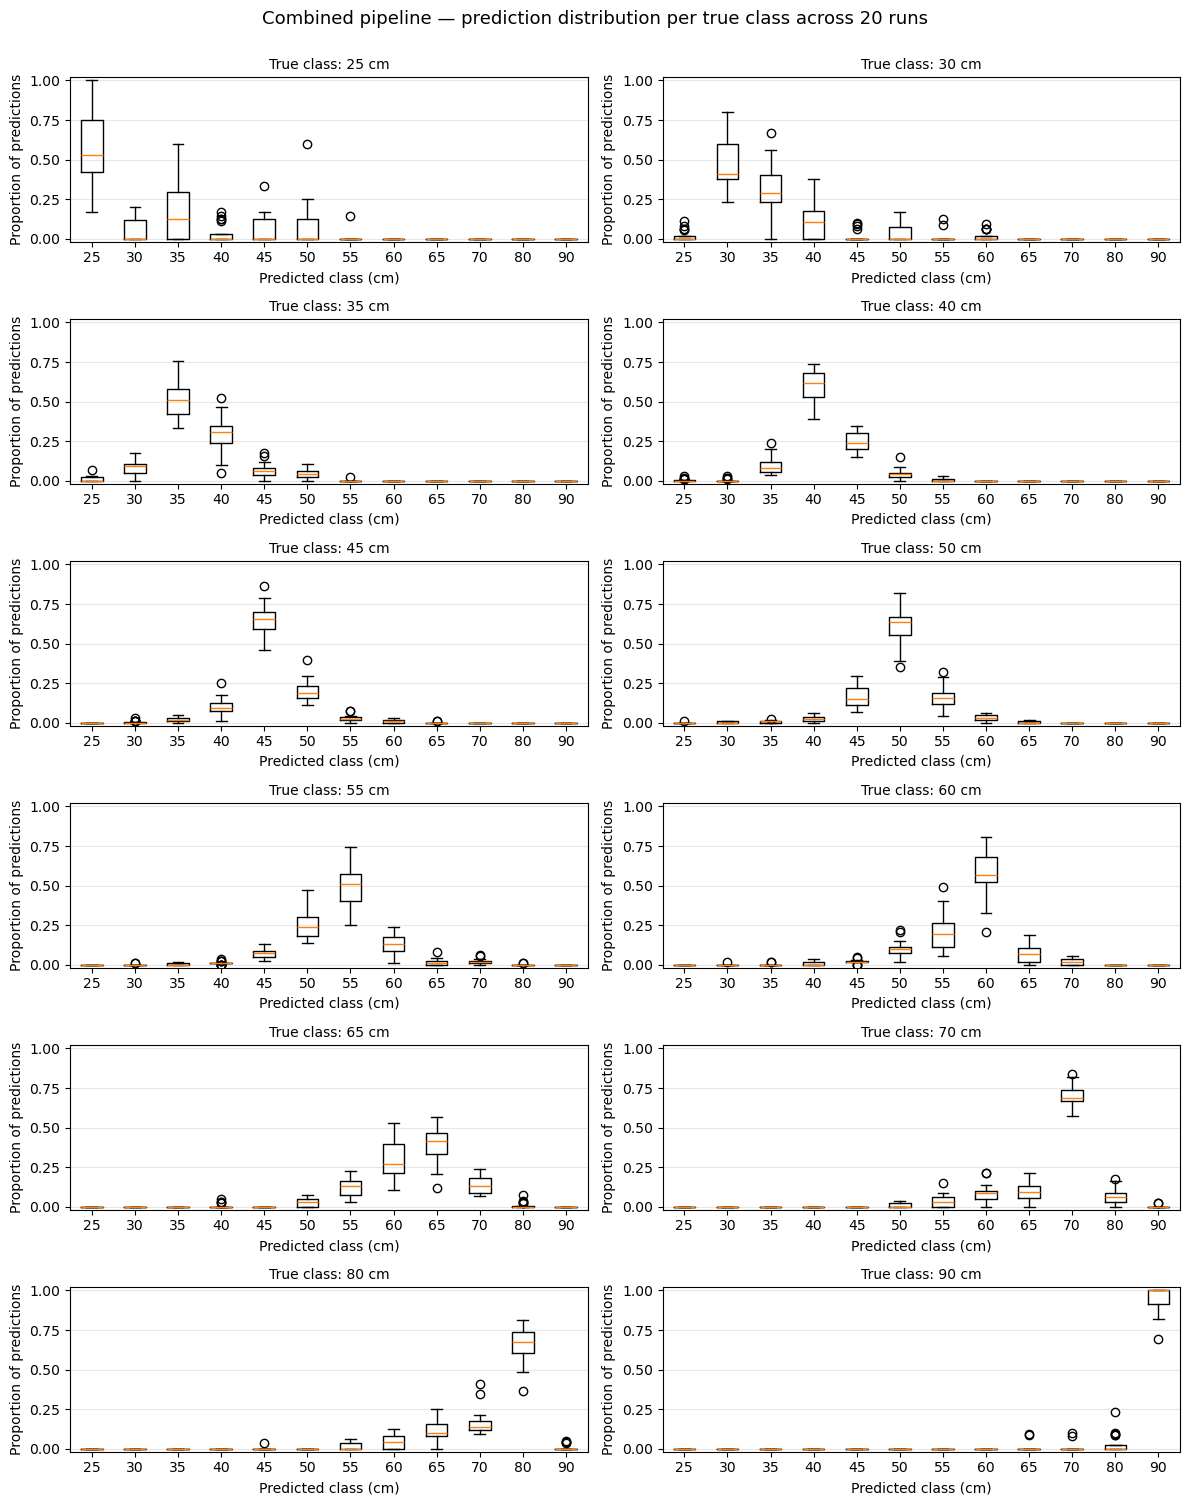

In [47]:
# ── Per-class prediction distribution box plots (Silva Figure 1 style) ────────
per_run_cm_combined_arr = np.array(per_run_cm_combined)  # (NUM_RUNS, NUM_BINS, NUM_BINS)


def plot_prediction_boxplots(per_run_cm, bin_labels, title, ncols=2):
    """
    Silva-style grid of box plots: one subplot per true class, showing the
    distribution across runs of the proportion of that true class predicted
    into each possible predicted class.
    """
    num_bins = per_run_cm.shape[1]
    nrows = (num_bins + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 2.5 * nrows))
    axes = axes.flatten()

    for i in range(num_bins):
        ax = axes[i]
        # Row i of each per-run CM: how true-class-i samples were distributed
        # across predicted classes. data[j] = vector of length NUM_RUNS.
        data = [per_run_cm[:, i, j] for j in range(num_bins)]
        ax.boxplot(data, labels=bin_labels, showfliers=True)
        ax.set_title(f'True class: {bin_labels[i]} cm', fontsize=10)
        ax.set_xlabel('Predicted class (cm)')
        ax.set_ylabel('Proportion of predictions')
        ax.set_ylim(-0.02, 1.02)
        ax.grid(axis='y', alpha=0.3)

    for k in range(num_bins, len(axes)):
        axes[k].axis('off')

    plt.suptitle(title, fontsize=13, y=1.00)
    plt.tight_layout()
    plt.show()


plot_prediction_boxplots(
    per_run_cm_combined_arr, BIN_LABELS,
    f'Combined pipeline — prediction distribution per true class across {NUM_RUNS} runs',
)

C:\Users\jettg\AppData\Local\Temp\ipykernel_18280\1719445443.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=bin_labels, showfliers=True)
C:\Users\jettg\AppData\Local\Temp\ipykernel_18280\1719445443.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=bin_labels, showfliers=True)
C:\Users\jettg\AppData\Local\Temp\ipykernel_18280\1719445443.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=bin_labels, showfliers=True)
C:\Users\jettg\AppData\Local\Temp\ipykernel_18280\1719445443.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of 

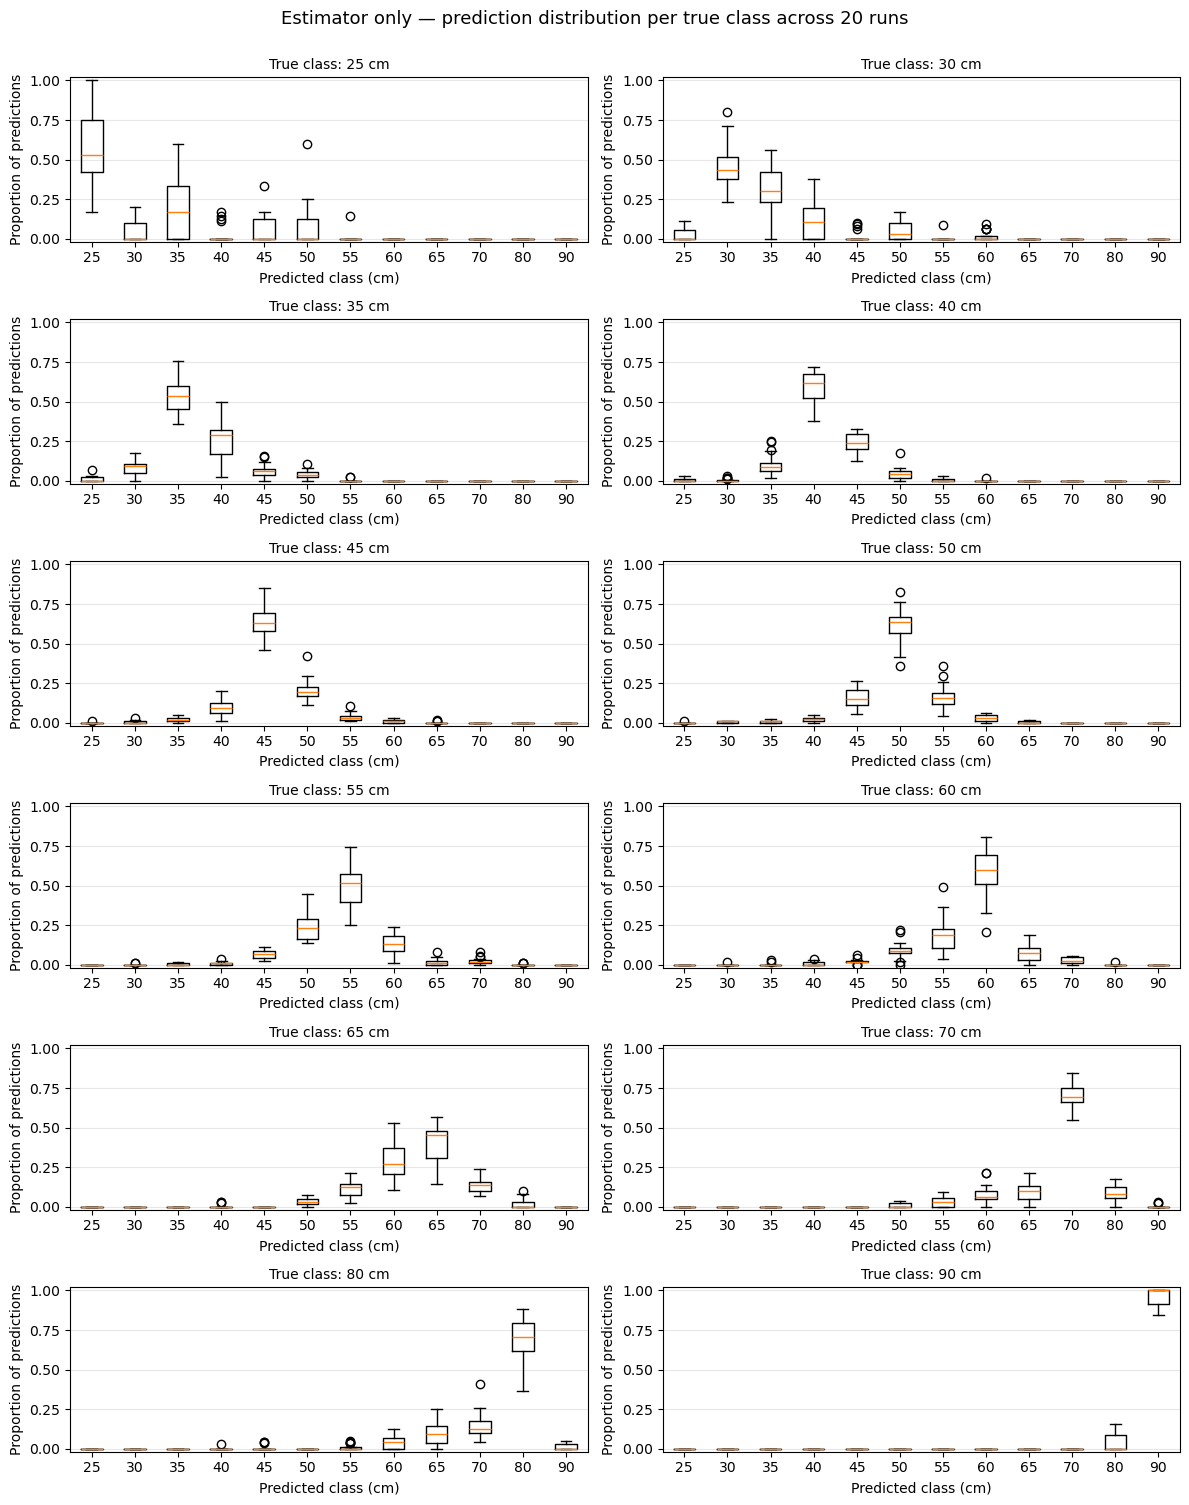

In [48]:
per_run_cm_estimator_arr = np.array(per_run_cm_estimator)
plot_prediction_boxplots(
    per_run_cm_estimator_arr, BIN_LABELS,
    f'Estimator only — prediction distribution per true class across {NUM_RUNS} runs',
)

## Experiemnt calculating the priors from training data


In [22]:
# ── Empirical biological priors from training set ─────────────────────────────
def build_empirical_prior_matrix(
    species_classes,
    num_bins,
    train_species,        # (N_fish,) species code per training fish (deduplicated)
    train_bin_idx,        # (N_fish,) bin index per training fish (deduplicated)
    smoothing='laplace',  # 'none' | 'laplace' | 'hybrid'
    alpha=1.0,            # Laplace pseudocount
    lam=0.7,              # hybrid: weight on empirical
    fallback_matrix=None, # required for 'hybrid', used for zero-count species
):
    """
    Compute P(bin | species) from training labels.

    IMPORTANT: pass fish-level (deduplicated) arrays, not per-view arrays,
    otherwise sample sizes are inflated 9x and smoothing is mis-calibrated.
    """
    num_species = len(species_classes)
    uniform = np.full(num_bins, 1.0 / num_bins, dtype=np.float32)
    matrix  = np.zeros((num_species, num_bins), dtype=np.float32)
    species_to_idx = {s: i for i, s in enumerate(species_classes)}

    counts = np.zeros((num_species, num_bins), dtype=np.float64)
    for sp, b in zip(train_species, train_bin_idx):
        if sp in species_to_idx:
            counts[species_to_idx[sp], b] += 1

    for i in range(num_species):
        n = counts[i].sum()
        if n == 0:
            matrix[i] = fallback_matrix[i] if fallback_matrix is not None else uniform
            continue
        if smoothing == 'laplace':
            row = counts[i] + alpha
            matrix[i] = row / row.sum()
        elif smoothing == 'hybrid':
            assert fallback_matrix is not None, "hybrid smoothing requires fallback_matrix"
            emp = counts[i] / n
            matrix[i] = lam * emp + (1 - lam) * fallback_matrix[i]
        else:  # 'none'
            matrix[i] = counts[i] / n

    return matrix.astype(np.float32)

In [23]:
# ── Sanity check: confirm 9 consecutive rows in pooled arrays = same fish ─────
# Cell 25 builds X_all_* by iterating fish then views, so this should hold.
# If pooling ever changes, this assert will catch silent leakage into the prior.
for i in range(0, min(len(y_all_species), 9 * 100), 9):
    assert (y_all_species[i:i+9] == y_all_species[i]).all(), \
        f'Views not contiguous at index {i} — fish-level dedup assumption broken'
    assert (y_all_bins[i:i+9] == y_all_bins[i]).all(), \
        f'Bins not contiguous at index {i} — fish-level dedup assumption broken'
print('Fish-level dedup assumption holds: 9 consecutive rows = one fish.')
print('Safe to use `idx[idx % 9 == 0]` to extract one row per fish.')

Fish-level dedup assumption holds: 9 consecutive rows = one fish.
Safe to use `idx[idx % 9 == 0]` to extract one row per fish.


In [24]:
# ── 20-run paired evaluation: YAML prior vs training-set priors ───────────────
from scipy import stats

PRIOR_CONFIGS = [
    ('yaml',                {}),                                       # baseline
    ('empirical_raw',       {'smoothing': 'none'}),                    # raw histogram
    ('empirical_laplace',   {'smoothing': 'laplace', 'alpha': 1.0}),   # add-1 smoothing
    ('hybrid_lam_0.25',     {'smoothing': 'hybrid', 'lam': 0.25}),
    ('hybrid_lam_0.50',     {'smoothing': 'hybrid', 'lam': 0.50}),
    ('hybrid_lam_0.75',     {'smoothing': 'hybrid', 'lam': 0.75}),
]

NUM_RUNS_EXP = 20
AUTOTUNE = tf.data.AUTOTUNE

results_by_config = {name: [] for name, _ in PRIOR_CONFIGS}

for run in range(NUM_RUNS_EXP):
    seed = run
    print(f'═══ Run {run + 1}/{NUM_RUNS_EXP}  (seed={seed}) ═══')

    # Split (same logic as cell 25 so results are directly comparable)
    idx = np.arange(len(X_all_224))
    idx_tr, idx_temp = train_test_split(idx, test_size=0.2, random_state=seed)
    idx_val, idx_te  = train_test_split(idx_temp, test_size=0.5, random_state=seed)

    X_tr_224 = X_all_224[idx_tr];  y_tr = y_all_bins[idx_tr]
    X_v_224  = X_all_224[idx_val]; X_v_75 = X_all_75[idx_val]; y_v = y_all_bins[idx_val]
    X_te_224 = X_all_224[idx_te];  X_te_75 = X_all_75[idx_te]; y_te = y_all_bins[idx_te]

    # Train fresh estimator (shared across all prior configs this run)
    train_ds = (tf.data.Dataset.from_tensor_slices((X_tr_224, y_tr))
                .shuffle(len(X_tr_224), seed=seed).batch(BATCH_SIZE).prefetch(AUTOTUNE))
    val_ds   = (tf.data.Dataset.from_tensor_slices((X_v_224, y_v))
                .batch(BATCH_SIZE).prefetch(AUTOTUNE))
    model = build_estimator(NUM_SIZE_BINS, trainable_backbone=False)
    model.fit(train_ds, validation_data=val_ds, epochs=ESTIMATOR_EPOCHS, verbose=0)

    # Predict once on val and test — reused across all prior configs
    est_probs_val = model.predict(X_v_224, verbose=0)
    sp_probs_val  = classifier.predict(X_v_75, verbose=0)
    est_probs_te  = model.predict(X_te_224, verbose=0)
    sp_probs_te   = classifier.predict(X_te_75, verbose=0)
    est_acc       = float(np.mean(np.argmax(est_probs_te, axis=1) == y_te))

    # Fish-level training labels for empirical priors (NO LEAKAGE: uses only idx_tr)
    train_fish_idx     = idx_tr[idx_tr % 9 == 0]
    train_species_fish = y_all_species[train_fish_idx]
    train_bins_fish    = y_all_bins[train_fish_idx]

    # Evaluate each prior strategy
    for name, kwargs in PRIOR_CONFIGS:
        if name == 'yaml':
            prior_mat = SPECIES_SIZE_PRIOR
        else:
            prior_mat = build_empirical_prior_matrix(
                species_le.classes_, NUM_SIZE_BINS,
                train_species_fish, train_bins_fish,
                fallback_matrix=SPECIES_SIZE_PRIOR,
                **kwargs,
            )

        prior_val = sp_probs_val @ prior_mat
        prior_te  = sp_probs_te  @ prior_mat

        # Sweep alpha on val
        ALPHAS = np.round(np.arange(0.0, 1.01, 0.05), 2)
        val_accs = [float(np.mean(np.argmax(a * est_probs_val + (1-a) * prior_val, axis=1) == y_v))
                    for a in ALPHAS]
        run_best_alpha = float(ALPHAS[int(np.argmax(val_accs))])

        # Evaluate at run-specific best alpha on test
        combined_te = run_best_alpha * est_probs_te + (1 - run_best_alpha) * prior_te
        comb_acc    = float(np.mean(np.argmax(combined_te, axis=1) == y_te))

        results_by_config[name].append({
            'run': run + 1, 'seed': seed,
            'best_alpha': run_best_alpha,
            'estimator_acc': est_acc,
            'combined_acc': comb_acc,
        })
        print(f'  [{name:<20}] α={run_best_alpha:.2f}  est={est_acc:.2%}  combined={comb_acc:.2%}')

    del model, est_probs_val, est_probs_te, sp_probs_val, sp_probs_te
    del X_tr_224, X_v_224, X_te_224, X_v_75, X_te_75
    tf.keras.backend.clear_session()

═══ Run 1/20  (seed=0) ═══
  [yaml                ] α=0.75  est=59.13%  combined=58.97%
  [empirical_raw       ] α=0.95  est=59.13%  combined=58.97%
  [empirical_laplace   ] α=0.90  est=59.13%  combined=58.97%
  [hybrid_lam_0.25     ] α=0.80  est=59.13%  combined=58.97%
  [hybrid_lam_0.50     ] α=0.60  est=59.13%  combined=58.01%
  [hybrid_lam_0.75     ] α=0.90  est=59.13%  combined=58.81%
═══ Run 2/20  (seed=1) ═══
  [yaml                ] α=0.45  est=55.45%  combined=55.77%
  [empirical_raw       ] α=0.95  est=55.45%  combined=55.77%
  [empirical_laplace   ] α=0.95  est=55.45%  combined=55.61%
  [hybrid_lam_0.25     ] α=0.55  est=55.45%  combined=55.61%
  [hybrid_lam_0.50     ] α=0.95  est=55.45%  combined=55.61%
  [hybrid_lam_0.75     ] α=0.95  est=55.45%  combined=55.45%
═══ Run 3/20  (seed=2) ═══
  [yaml                ] α=0.35  est=56.09%  combined=56.41%
  [empirical_raw       ] α=0.85  est=56.09%  combined=56.09%
  [empirical_laplace   ] α=0.70  est=56.09%  combined=56.57%
  [h

Config                 Combined acc         α (mean)   Δ vs est-only 
----------------------------------------------------------------------
yaml                   58.77% ± 2.06%      0.61      -0.06%
empirical_raw          58.85% ± 2.51%      0.80      +0.02%
empirical_laplace      59.00% ± 2.50%      0.75      +0.17%
hybrid_lam_0.25        58.87% ± 2.14%      0.65      +0.04%
hybrid_lam_0.50        58.69% ± 2.52%      0.72      -0.14%
hybrid_lam_0.75        58.93% ± 2.39%      0.77      +0.10%

Paired t-test vs yaml baseline (per-run differences):
  empirical_raw          Δ=+0.08%  t=+0.49  p=0.6295  
  empirical_laplace      Δ=+0.23%  t=+1.44  p=0.1670  
  hybrid_lam_0.25        Δ=+0.10%  t=+0.83  p=0.4183  
  hybrid_lam_0.50        Δ=-0.07%  t=-0.47  p=0.6459  
  hybrid_lam_0.75        Δ=+0.16%  t=+0.97  p=0.3443  


C:\Users\jettg\AppData\Local\Temp\ipykernel_18280\2348938315.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showmeans=True)


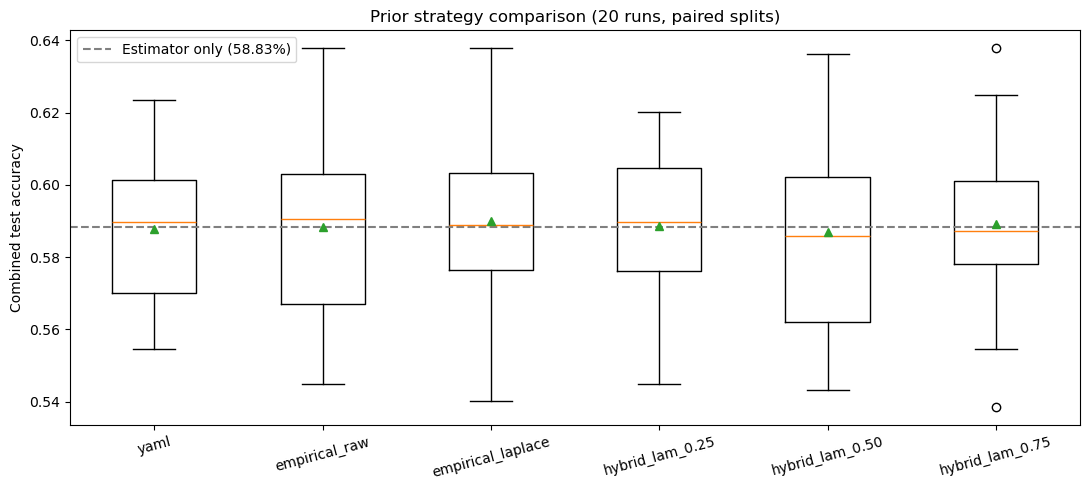

In [25]:
# ── Summary table ─────────────────────────────────────────────────────────────
print(f'{"Config":<22} {"Combined acc":<20} {"α (mean)":<10} {"Δ vs est-only":<14}')
print('-' * 70)
for name, _ in PRIOR_CONFIGS:
    df_c = pd.DataFrame(results_by_config[name])
    comb_mean, comb_std = df_c['combined_acc'].mean(), df_c['combined_acc'].std()
    est_mean   = df_c['estimator_acc'].mean()
    alpha_mean = df_c['best_alpha'].mean()
    print(f'{name:<22} {comb_mean:.2%} ± {comb_std:.2%}      '
          f'{alpha_mean:.2f}      {comb_mean - est_mean:+.2%}')

# ── Paired t-tests vs YAML baseline ───────────────────────────────────────────
# Valid because every config sees the exact same splits and trained estimator each run.
yaml_accs = np.array([r['combined_acc'] for r in results_by_config['yaml']])
print('\nPaired t-test vs yaml baseline (per-run differences):')
for name, _ in PRIOR_CONFIGS:
    if name == 'yaml':
        continue
    other = np.array([r['combined_acc'] for r in results_by_config[name]])
    t, p = stats.ttest_rel(other, yaml_accs)
    diff = (other - yaml_accs).mean()
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'  {name:<22} Δ={diff:+.2%}  t={t:+.2f}  p={p:.4f}  {sig}')

# ── Box plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
data   = [[r['combined_acc'] for r in results_by_config[name]] for name, _ in PRIOR_CONFIGS]
labels = [name for name, _ in PRIOR_CONFIGS]
ax.boxplot(data, labels=labels, showmeans=True)
est_baseline = np.mean([r['estimator_acc'] for r in results_by_config['yaml']])
ax.axhline(est_baseline, ls='--', color='gray',
           label=f'Estimator only ({est_baseline:.2%})')
ax.set_ylabel('Combined test accuracy')
ax.set_title(f'Prior strategy comparison ({NUM_RUNS_EXP} runs, paired splits)')
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()